# EDA 08: DepMap Omics Profiles (bridge table)

## Purpose

`8_DepMap_OmicsProfiles.csv` is small (3,830 rows) but load-bearing: it is the **only** table that
resolves a `ProfileID` (a sequencing run) to a `ModelID` (a cell line). Every join from RNA
(notebook 02), mutations (notebook 06), or copy number (notebook 16) back to the identity spine
(notebook 09) passes through this table. Getting its filtering wrong (not restricting `Datatype`
before joining) silently duplicates cell lines downstream — this notebook establishes exactly how.

**Source, release, grain:** DepMap sequencing-run registry. One row per `ProfileID`. 3,830 rows —
1,495 RNA, 1,860 WES (exome), 475 WGS (whole-genome).

## Questions this notebook must answer

1. Is `ProfileID` unique (one row per sequencing run), and is `ModelID` populated for all of them?
2. How many sequencing runs does the typical cell line carry, and of which types?
3. Which combination of assay types (`rna`, `wes`, `wgs`) does each model have — which lines are
   "multi-omics-ready" with all three?
4. How many of the primary identity spine's cell lines (file 9) have *no* sequencing profile at
   all here?

**Interpretation rule:** this table is a bridge, not a measurement — it has no
`measured`/`measured_absent` states of its own. A model with zero rows here is `not_assayed` for
every ProfileID-keyed layer simultaneously (RNA, mutations, copy number), which is a stronger
statement than being `not_assayed` for just one of them.

## Column dictionary

| Column | Meaning | Notes |
|---|---|---|
| `ProfileID` | sequencing-run key (`PR-...`) | primary key of this table |
| `ModelID` | DepMap cell-line key (`ACH-...`) | join target — file 9's `DepMap_ID` |
| `Datatype` | `rna` / `wes` / `wgs` | **filter to one value before joining** — otherwise a model with multiple run types joins multiple times |
| `WESKit` | exome capture kit used | only populated for `wes` rows |

## 1. Basic data contract and schema audit

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
df = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv')
print(f"Rows                : {len(df)}")
print(f"Unique ProfileID    : {df['ProfileID'].nunique()}")
print(f"Unique ModelID      : {df['ModelID'].nunique()}")
df['Datatype'].value_counts()

Rows                : 3830
Unique ProfileID    : 3830
Unique ModelID      : 1822


Datatype
wes    1860
rna    1495
wgs     475
Name: count, dtype: int64

### Why this EDA check matters

Confirms `ProfileID` is genuinely a primary key (no duplicate rows) and gives the real per-datatype
counts against which every downstream `Datatype == '...'` filter can be checked.

## 2. Sequencing runs per model, and assay-type combinations

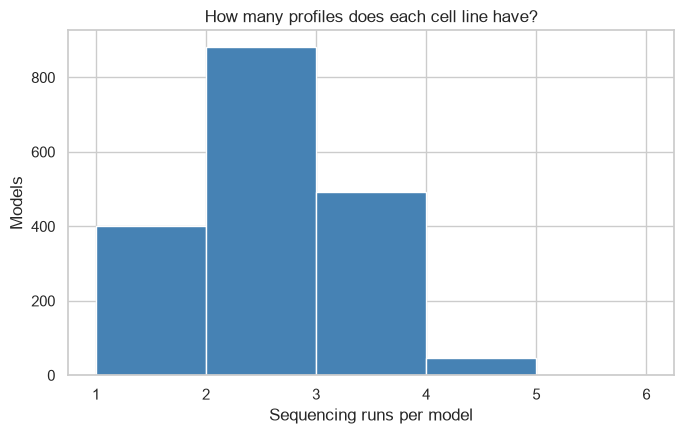

In [3]:
profiles_per_model = df.groupby('ModelID')['ProfileID'].count()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(profiles_per_model, bins=range(1, profiles_per_model.max() + 2), color='steelblue', edgecolor='white')
ax.set_xlabel('Sequencing runs per model'); ax.set_ylabel('Models')
ax.set_title('How many profiles does each cell line have?')
plt.tight_layout(); plt.show()

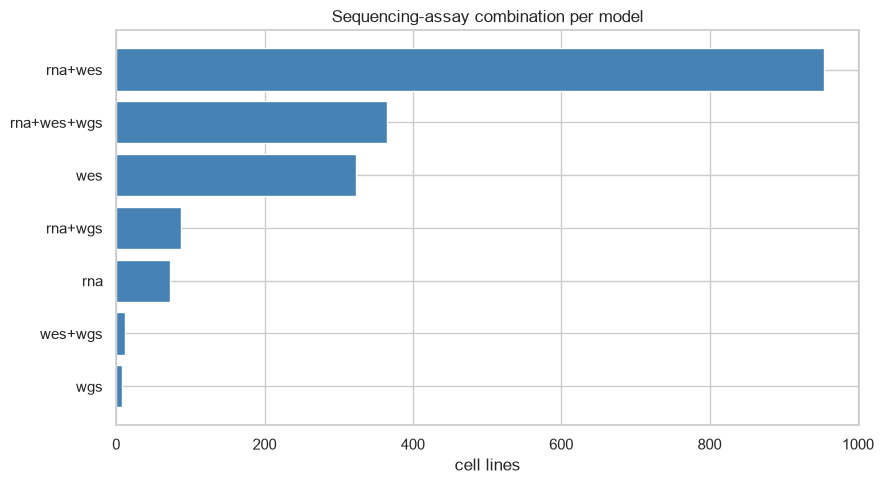

Fully characterised (rna+wes+wgs): 365 models


In [4]:
combo = df.groupby('ModelID')['Datatype'].apply(lambda s: '+'.join(sorted(set(s))))
vc = combo.value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(vc.index[::-1], vc.values[::-1], color='steelblue')
ax.set_xlabel('cell lines'); ax.set_title('Sequencing-assay combination per model')
plt.tight_layout(); plt.show()
print(f"Fully characterised (rna+wes+wgs): {vc.get('rna+wes+wgs', 0)} models")

### Why this EDA check matters

A model with more than one profile of the *same* `Datatype` is exactly the non-unique-key trap
`docs/PROJECT_ARCHITECTURE.md` §2 and notebook 02 flagged for RNA — this confirms whether that
pattern exists here for WES/WGS too, and the assay-combination chart tells `preprocess.py` which
models can support a true multi-omics comparison versus a partial one.

## 3. Coverage gap against the primary identity spine

In [5]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage'])
df9_models = set(df9['DepMap_ID'].dropna())
bridge_models = set(df['ModelID'].dropna())

no_profile = df9[~df9['DepMap_ID'].isin(bridge_models)]
print(f"Primary spine models (file 9)         : {len(df9_models)}")
print(f"Models with at least one profile here  : {len(bridge_models & df9_models)} ({len(bridge_models & df9_models)/len(df9_models):.1%})")
print(f"Models with NO sequencing profile      : {len(no_profile)}")
print()
print("Lineages of models with no sequencing profile at all (top 10):")
print(no_profile['lineage'].value_counts().head(10).to_string())

Primary spine models (file 9)         : 1840
Models with at least one profile here  : 1749 (95.1%)
Models with NO sequencing profile      : 91

Lineages of models with no sequencing profile at all (top 10):
lineage
breast                    17
lung                      11
bone                      10
skin                       7
colorectal                 6
central_nervous_system     5
kidney                     4
soft_tissue                4
upper_aerodigestive        4
blood                      3


### Why this EDA check matters

A model in file 9 with zero rows here has metadata (name, lineage, disease) but no omics
measurement of any kind reachable through this bridge — it can appear in a filter but can never
receive a per-gene evidence score. Distinguishing this from a model that simply lacks one specific
assay type matters for how "no evidence at all" is reported versus "missing this one layer.\"

## Decisions carried into the next notebooks

1. **Always filter `Datatype` to exactly one value before joining `ProfileID` anywhere** —
   `'rna'` for expression, `'wes'`/`'wgs'` for mutation/copy-number bridging.
2. A model can carry more than one profile of the same `Datatype` — resolve to a default profile
   before any per-model score, same trap as notebook 02.
3. §3's "no profile at all" set is a distinct, stronger missing-evidence case than "missing one
   layer" — worth surfacing separately on a result card (a line with zero omics evidence should be
   listed under insufficient evidence per `scratchpad/kausty/v5/PLAN.md` §5, not silently ranked).